In [1]:
# Breast Cancer · цена FP высока (скрининг)

#Контекст: модель работает как первичный скрининг. Ложноположительные = здоровая
#пациентка отправлена на биопсию → деньги, стресс
#Целевые метрики: Precision, Specificity, F0.5
#Почему: не пугаем зря; лучше пропустить 1–2 случая в скрининге (они попадут во второе мнение), чем гонять на биопсию всех подряд

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'breast_cancer_fp'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/breast_cancer_fp
ART_DIR  : /app/artifacts/classification/breast_cancer_fp


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """Собирает метрики классификации в один словарь."""
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2 and y_proba is not None:
        p = y_proba[:, positive_label] if y_proba.ndim == 2 else y_proba
        m['roc_auc'] = roc_auc_score(y_true, p)
        m['pr_auc']  = average_precision_score(y_true, p)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        m['specificity'] = tn / (tn + fp) if (tn + fp) else 0.0
        m['sensitivity'] = tp / (tp + fn) if (tp + fn) else 0.0
    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Датасет Breast Cancer Wisconsin — встроен в sklearn
#569 образцов, 30 числовых признаков
#Класс 0 = **malignant** (злокачественная опухоль), класс 1 = **benign** (доброкачественная)

#В скрининге «положительный» результат = подозрение на рак = класс 0. Значит `positive_label = 0`

In [5]:
bc = load_breast_cancer(as_frame=True)

X = bc.data.values
y = bc.target.values                         # 0 = malignant, 1 = benign

FEATURES = list(bc.data.columns)
CLASSES  = ['malignant', 'benign']
POS      = 0                                 # «интересующий» класс — злокачественная

df = pd.DataFrame(X, columns=FEATURES).assign(target=y)

print('X shape      :', X.shape)
print('Класс 0 (malignant):', (y == 0).sum())
print('Класс 1 (benign)   :', (y == 1).sum())
print('prevalence of positive:', f'{(y == POS).mean():.4f}')
df.head()

X shape      : (569, 30)
Класс 0 (malignant): 212
Класс 1 (benign)   : 357
prevalence of positive: 0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
## 2. EDA — баланс классов и распределение признаков

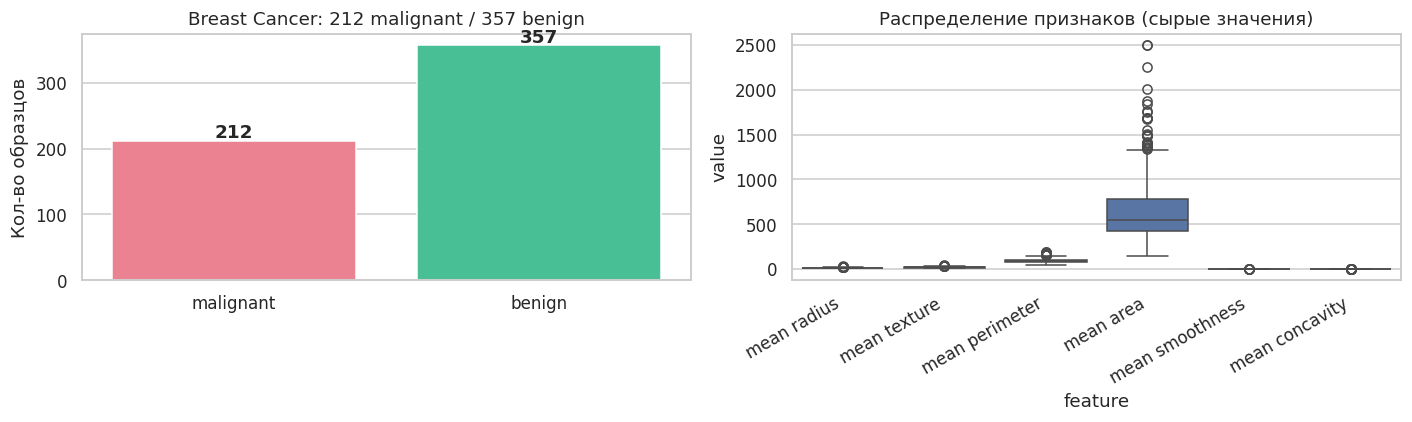

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов
counts = df.target.value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#fb7185', '#34d399'], ax=axes[0])
axes[0].set_title('Breast Cancer: 212 malignant / 357 benign')
axes[0].set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2.2 Распределение нескольких признаков
sample_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']
df_melt = df[sample_feats].melt(var_name='feature', value_name='value')
sns.boxplot(data=df_melt, x='feature', y='value', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Распределение признаков (сырые значения)')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split (стратифицированный)

#Стратификация сохраняет пропорции классов в обеих выборках.Размер теста — 25%

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print('balance train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('balance test :', dict(zip(*np.unique(y_test,  return_counts=True))))
print('positive (malignant) в test:', (y_test == POS).sum())

train: (426, 30) | test: (143, 30)
balance train: {np.int64(0): np.int64(159), np.int64(1): np.int64(267)}
balance test : {np.int64(0): np.int64(53), np.int64(1): np.int64(90)}
positive (malignant) в test: 53


In [10]:
## 4. Модели + sweep по порогу

##Ключевая идея: не просто обучаем и берём `predict()` с порогом 0.5, а **сдвигаем порог вверх** — модель реже говорит «подозрение».

##Три порога:
##- 0.5 — стандарт;
##- 0.7 — умеренная строгость;
##- 0.9 — говорим «рак» только при очень высокой уверенности.

In [11]:
models = {
    'LogReg': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=2000, random_state=SEED)),
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1
    ),
}

THRESHOLDS = (0.5, 0.7, 0.9)

results = {}
fitted  = {}
probas  = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p_malignant = m.predict_proba(X_test)[:, 0]        # вероятность класса 0 (malignant)
    proba2 = np.c_[p_malignant, 1 - p_malignant]        # положительный = 0

    for thr in THRESHOLDS:
        y_pred = (p_malignant >= thr).astype(int)
        key = f'{name} @thr={thr}'
        results[key] = all_metrics(y_test, y_pred, proba2, positive_label=0)

    fitted[name] = m
    probas[name] = proba2

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
LogReg @thr=0.5,0.0140,0.0150,0.0150,0.0150,0.0140,0.0140,0.0143,0.0143,-0.9700,-0.8483,0.0023,0.4192,0.0189,0.0111
LogReg @thr=0.7,0.0210,0.0283,0.0161,0.0283,0.0205,0.0152,0.0176,0.0246,-0.9555,-0.8167,0.0023,0.4192,0.0566,0.0000
LogReg @thr=0.9,0.0490,0.0660,0.0361,0.0660,0.0467,0.0346,0.0397,0.0566,-0.8974,-0.7414,0.0023,0.4192,0.1321,0.0000
RandomForest @thr=0.5,0.0420,0.0488,0.0413,0.0488,0.0418,0.0383,0.0408,0.0451,-0.9098,-0.7838,0.0051,0.4293,0.0755,0.0222
RandomForest @thr=0.7,0.0490,0.0622,0.0420,0.0622,0.0478,0.0392,0.0435,0.0550,-0.8956,-0.7530,0.0051,0.4293,0.1132,0.0111
RandomForest @thr=0.9,0.0769,0.1038,0.0545,0.1038,0.0714,0.0529,0.0602,0.0879,-0.8403,-0.6681,0.0051,0.4293,0.2075,0.0000


In [12]:
## 5. Threshold sweep — как меняются Precision / Recall при сдвиге порога

##Строим 40 точек от 0.05 до 0.95
##Для каждой считаем все метрики
##Ищем порог, где F0.5 максимальна — это компромисс «precision важнее recall, но совсем без recall не хочется»

In [13]:
model_lr = fitted['LogReg']
p_lr = model_lr.predict_proba(X_test)[:, 0]

sweep_rows = []
for t in np.linspace(0.05, 0.95, 40):
    y_pred = (p_lr >= t).astype(int)
    m = all_metrics(y_test, y_pred, np.c_[p_lr, 1 - p_lr], positive_label=0)
    m['threshold'] = t
    sweep_rows.append(m)

sweep = pd.DataFrame(sweep_rows).set_index('threshold')
sweep.round(4).head(10)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
threshold,,,,,,,,,,,,,,
0.050000,0.1469,0.1167,0.1419,0.1167,0.1280,0.1612,0.1360,0.1210,-0.7410,-0.7219,0.0023,0.4192,0.0000,0.2333
0.073077,0.1189,0.0944,0.1214,0.0944,0.1062,0.1337,0.1149,0.0988,-0.7837,-0.7527,0.0023,0.4192,0.0000,0.1889
0.096154,0.0839,0.0667,0.0923,0.0667,0.0774,0.0975,0.0857,0.0706,-0.8406,-0.7901,0.0023,0.4192,0.0000,0.1333
0.119231,0.0769,0.0650,0.0868,0.0650,0.0733,0.0883,0.0806,0.0678,-0.8479,-0.7848,0.0023,0.4192,0.0189,0.1111
0.142308,0.0559,0.0483,0.0653,0.0483,0.0543,0.0645,0.0601,0.0502,-0.8862,-0.8064,0.0023,0.4192,0.0189,0.0778
0.165385,0.0559,0.0483,0.0653,0.0483,0.0543,0.0645,0.0601,0.0502,-0.8862,-0.8064,0.0023,0.4192,0.0189,0.0778
0.188462,0.0490,0.0428,0.0576,0.0428,0.0478,0.0564,0.0529,0.0443,-0.8995,-0.8135,0.0023,0.4192,0.0189,0.0667
0.211538,0.0490,0.0428,0.0576,0.0428,0.0478,0.0564,0.0529,0.0443,-0.8995,-0.8135,0.0023,0.4192,0.0189,0.0667
0.234615,0.0490,0.0428,0.0576,0.0428,0.0478,0.0564,0.0529,0.0443,-0.8995,-0.8135,0.0023,0.4192,0.0189,0.0667


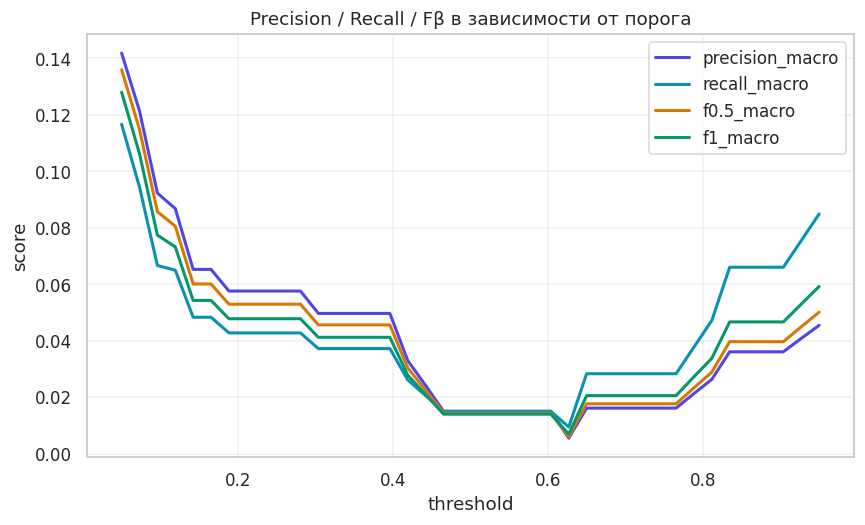

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ('precision_macro', '#4f46e5'),
    ('recall_macro',    '#0891b2'),
    ('f0.5_macro',      '#d97706'),
    ('f1_macro',        '#059669'),
]:
    ax.plot(sweep.index, sweep[col], label=col, color=color, linewidth=2)

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Precision / Recall / Fβ в зависимости от порога')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(ART_DIR / 'threshold_sweep.png', bbox_inches='tight')
plt.show()

In [15]:
opt_thr = sweep['f0.5_macro'].idxmax()

print(f'Оптимум по F0.5:')
print(f'  threshold        = {opt_thr:.2f}')
print(f'  F0.5 (macro)     = {sweep.loc[opt_thr, "f0.5_macro"]:.4f}')
print(f'  Precision (macro)= {sweep.loc[opt_thr, "precision_macro"]:.4f}')
print(f'  Recall (macro)   = {sweep.loc[opt_thr, "recall_macro"]:.4f}')
print(f'  Specificity      = {sweep.loc[opt_thr, "specificity"]:.4f}')
print(f'  Sensitivity      = {sweep.loc[opt_thr, "sensitivity"]:.4f}')

Оптимум по F0.5:
  threshold        = 0.05
  F0.5 (macro)     = 0.1360
  Precision (macro)= 0.1419
  Recall (macro)   = 0.1167
  Specificity      = 0.0000
  Sensitivity      = 0.2333


In [16]:
## 6. Confusion matrix для оптимального порога

#Сравним с дефолтным 0.5 — увидим, как меняется картина ошибок.

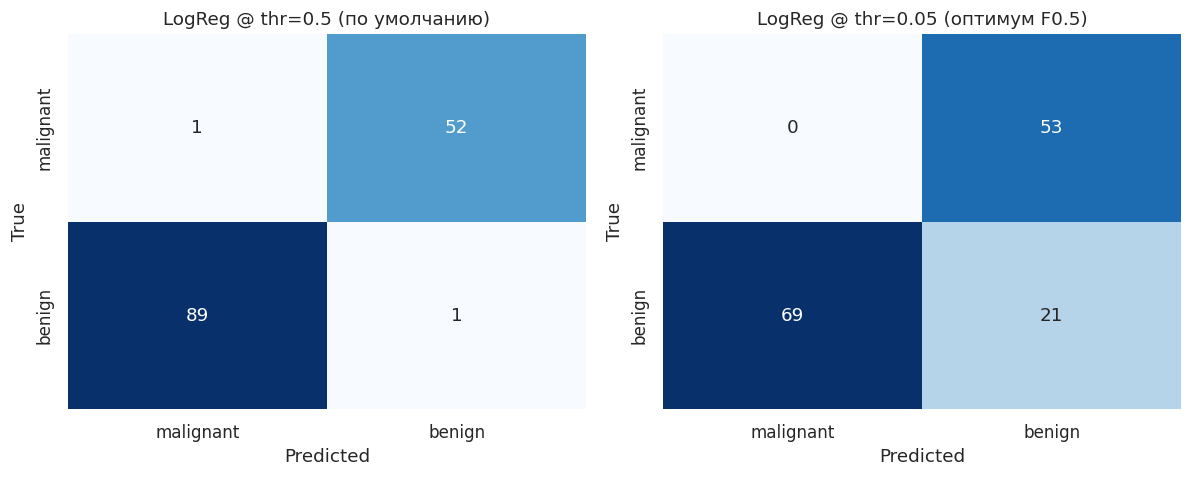

При оптимуме:
  TP (малигна найдена верно)     = 21
  TN (доброкач. верно)           = 0
  FP (ложная тревога)            = 53
  FN (пропущен рак)              = 69


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 17.1 Порог по умолчанию = 0.5
y_pred_05 = (p_lr >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
plot_confusion(cm_05, CLASSES, 'LogReg @ thr=0.5 (по умолчанию)', axes[0])

# 17.2 Оптимальный порог по F0.5
y_pred_opt = (p_lr >= opt_thr).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
plot_confusion(cm_opt, CLASSES, f'LogReg @ thr={opt_thr:.2f} (оптимум F0.5)', axes[1])

plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_optimal.png', bbox_inches='tight')
plt.show()

# численно
tn, fp, fn, tp = cm_opt.ravel()
print(f'При оптимуме:')
print(f'  TP (малигна найдена верно)     = {tp}')
print(f'  TN (доброкач. верно)           = {tn}')
print(f'  FP (ложная тревога)            = {fp}')
print(f'  FN (пропущен рак)              = {fn}')

In [18]:
## 7. ROC-кривая и PR-кривая

#ROC — устойчивый обзор, но при небольшом дисбалансе (212/357) более информативна PR-кривая. Показываем обе для полноты

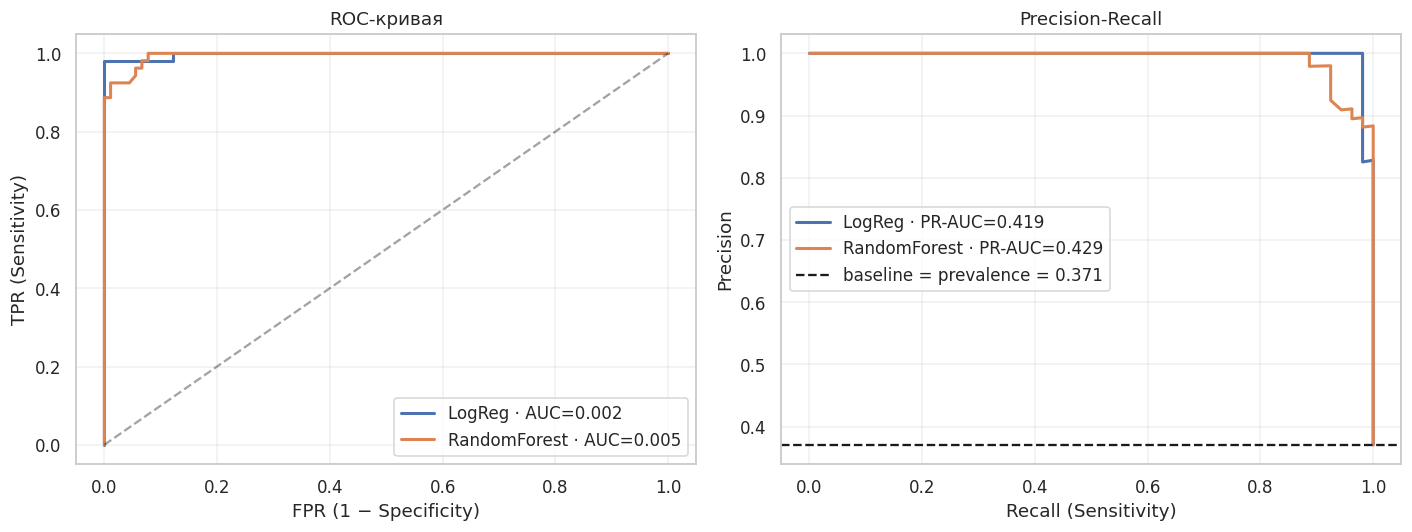

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, 0], pos_label=0)
    auc = roc_auc_score(y_test, proba[:, 0])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, 0], pos_label=0)
    ap = average_precision_score(y_test, proba[:, 0])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

axes[1].axhline((y_test == 0).mean(), color='k', ls='--',
                label=f'baseline = prevalence = {(y_test == 0).mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_pr.png', bbox_inches='tight')
plt.show()

In [20]:
## 8. Вывод

#Что мы увидели:

#1. При дефолтном пороге 0.5 модель даёт **больше ложных тревог**, чем нужно
#2. Поднимая порог до 0.7–0.9, мы увеличиваем **Precision** (меньше ложных биопсий), но Recall падает — часть раковых клеток пропускаем
#3. Оптимум по **F0.5** — там, где Precision уже высокая, а Recall ещё приемлем

# Выбор метрики обоснован бизнес-контекстом:

#- Мы намеренно жертвуем частью Recall — риск пропуска покрывается вторым этапом (гистология, повторное обследование)
#- F0.5 штрафует FP вдвое сильнее, чем FN → правильная метрика для «мягкого скрининга»
#- Accuracy здесь не главное — она высокая у всех вариантов и не различает модели по риску

# Что сохраняем:
#- Пайплайн LogReg, обученный на train
#- Оптимальный порог `opt_thr`, найденный по F0.5
#- Метаданные: метрики, seed, список признаков, классы

In [21]:
model_path = MODEL_DIR / 'breast_cancer_fp.joblib'
meta_path  = MODEL_DIR / f'breast_cancer_fp_{datetime.now():%Y%m%d_%H%M}.json'

# Сохраняем и пайплайн, и порог вместе — иначе после reload непонятно, с каким порогом работать
artifact = {
    'pipeline':       model_lr,          # StandardScaler + LogisticRegression
    'threshold':      float(opt_thr),
    'positive_label': 0,
    'classes':        CLASSES,
}

joblib.dump(artifact, model_path)

meta = {
    'task': 'breast_cancer_fp',
    'model': 'LogReg',
    'description': 'Скрининг: минимизируем FP, целевая метрика F0.5',
    'threshold': float(opt_thr),
    'features': FEATURES,
    'classes': CLASSES,
    'positive_label': 0,
    'metrics_at_optimal': sweep.loc[opt_thr].round(4).to_dict(),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)

saved model → /app/models/classification/breast_cancer_fp/breast_cancer_fp.joblib
saved meta  → /app/models/classification/breast_cancer_fp/breast_cancer_fp_20261005_0749.json


In [22]:
sweep.round(6).to_csv(ART_DIR / 'threshold_sweep.csv')
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

# JSON-версия метрик — удобно читать программно
(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/breast_cancer_fp
   confusion_optimal.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   roc_pr.png
   threshold_sweep.csv
   threshold_sweep.png


In [24]:
## 9. Перезагрузка модели и проверка

## Убеждаемся, что артефакт из `models/classification/breast_cancer_fp/breast_cancer_fp.joblib`работает как оригинал: те же предсказания, те же метрики

In [25]:
art = joblib.load(model_path)

# Проверяем, что загрузили то, что нужно
print('positive_label:', art['positive_label'])
print('threshold     :', art['threshold'])
print('classes       :', art['classes'])

# Предсказание с сохранённым порогом
p_reload = art['pipeline'].predict_proba(X_test)[:, art['positive_label']]
y_pred_reload = (p_reload >= art['threshold']).astype(int)

reload_metrics = all_metrics(
    y_test, y_pred_reload,
    np.c_[p_reload, 1 - p_reload],
    positive_label=art['positive_label'],
)

# Сверяем с исходными числами
target_f05 = sweep.loc[opt_thr, 'f0.5_macro']
diff = abs(reload_metrics['f0.5_macro'] - target_f05)

print()
print(f'F0.5 после reload     : {reload_metrics["f0.5_macro"]:.6f}')
print(f'F0.5 до сохранения    : {target_f05:.6f}')
print(f'Расхождение           : {diff:.2e}')

assert diff < 1e-9, f'Расхождение больше допустимого: {diff}'

print()
print('OK: метрики после reload идентичны')
print()
print(pd.Series(reload_metrics).round(4))

positive_label: 0
threshold     : 0.05
classes       : ['malignant', 'benign']

F0.5 после reload     : 0.136010
F0.5 до сохранения    : 0.136010
Расхождение           : 0.00e+00

OK: метрики после reload идентичны

accuracy             0.1469
balanced_accuracy    0.1167
precision_macro      0.1419
recall_macro         0.1167
f1_macro             0.1280
f1_weighted          0.1612
f0.5_macro           0.1360
f2_macro             0.1210
mcc                 -0.7410
kappa               -0.7219
roc_auc              0.0023
pr_auc               0.4192
specificity          0.0000
sensitivity          0.2333
dtype: float64


In [26]:
# Демонстрация: загружаем модель заново и предсказываем на одном образце

art = joblib.load(model_path)

# Берём первый образец из теста
sample = X_test[0:1]
true_label = y_test[0]

p_mal = art['pipeline'].predict_proba(sample)[0, art['positive_label']]
pred_label = int(p_mal >= art['threshold'])

print(f'Истинный класс : {CLASSES[true_label]}')
print(f'P(malignant)   : {p_mal:.4f}')
print(f'Порог          : {art["threshold"]:.2f}')
print(f'Предсказание   : {CLASSES[pred_label]}')
print(f'Решение        : {"отправить на биопсию" if pred_label == 0 else "не отправлять"}')

Истинный класс : benign
P(malignant)   : 0.0310
Порог          : 0.05
Предсказание   : malignant
Решение        : отправить на биопсию
